In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

results = pd.read_csv("../package_metadata/results_all.csv")

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_inverse_multiquadric": "#F5B027",
    "kt_sobolev": "gray",
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#32527B",
    "kt_stratified": "#81b29a",
    "kt_predictions": "#f08060"
}

results_sobolev = results[results["method_total"] == "kt_sobolev"]
results_sobolev['unique_samples'].unique()

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_3493/3439063686.py:6: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")


array([1, 2, 3, 5, 4])

# Image 0

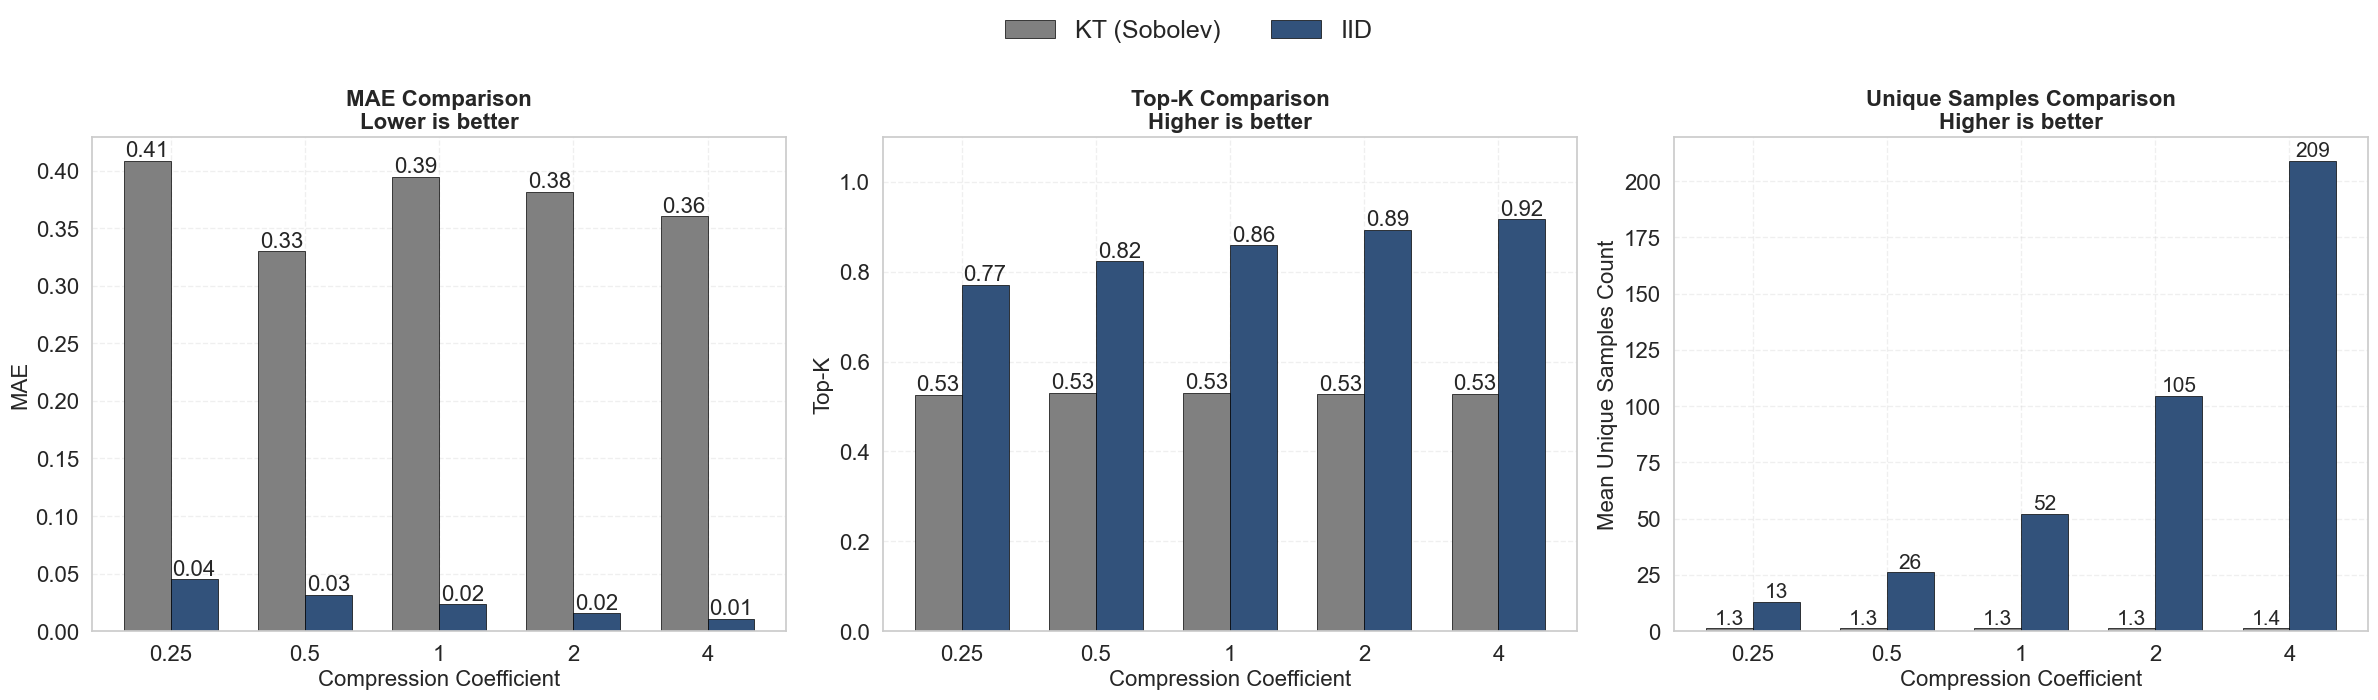

In [48]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
results_sobolev = results_aggregated[results_aggregated["method_total"] == "kt_sobolev"]
results_iid = results_aggregated[results_aggregated["method_total"] == "iid"]

data_cols = ["mae_mean", "top_k_mean", "unique_samples_mean"]
coeffs_to_keep = [0.25, 0.5, 1, 2, 4]

sobolev_agg = results_sobolev.groupby("compression_coefficient")[data_cols].mean().reset_index()
iid_agg = results_iid.groupby("compression_coefficient")[data_cols].mean().reset_index()

sobolev_agg = sobolev_agg[sobolev_agg["compression_coefficient"].isin(coeffs_to_keep)].sort_values("compression_coefficient")
iid_agg = iid_agg[iid_agg["compression_coefficient"].isin(coeffs_to_keep)].sort_values("compression_coefficient")

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

x_positions = np.arange(len(coeffs_to_keep))
bar_width = 0.35

sobolev_color = 'gray'
iid_color = '#32527B'

mae_sobolev = sobolev_agg['mae_mean'].values
mae_iid = iid_agg['mae_mean'].values

rects1 = axes[0].bar(x_positions - bar_width/2, mae_sobolev, width=bar_width, color=sobolev_color, label='Sobolev', edgecolor='black', linewidth=0.5)
rects2 = axes[0].bar(x_positions + bar_width/2, mae_iid, width=bar_width, color=iid_color, label='IID', edgecolor='black', linewidth=0.5)
axes[0].set_title("MAE Comparison\nLower is better", fontweight='bold')
axes[0].set_ylabel("MAE", fontsize=16)

for i, (val_sob, val_iid) in enumerate(zip(mae_sobolev, mae_iid)):
    axes[0].text(i - bar_width/2, val_sob, f'{val_sob:.2f}', ha='center', va='bottom', fontsize=16)
    axes[0].text(i + bar_width/2, val_iid, f'{val_iid:.2f}', ha='center', va='bottom', fontsize=16)

topk_sobolev = sobolev_agg['top_k_mean'].values
topk_iid = iid_agg['top_k_mean'].values

axes[1].bar(x_positions - bar_width/2, topk_sobolev, width=bar_width, color=sobolev_color, edgecolor='black', linewidth=0.5)
axes[1].bar(x_positions + bar_width/2, topk_iid, width=bar_width, color=iid_color, edgecolor='black', linewidth=0.5)
axes[1].set_title("Top-K Comparison\nHigher is better", fontweight='bold')
axes[1].set_ylabel("Top-K", fontsize=16)
axes[1].set_ylim(0, 1.1)
axes[1].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

for i, (val_sob, val_iid) in enumerate(zip(topk_sobolev, topk_iid)):
    axes[1].text(i - bar_width/2, val_sob, f'{val_sob:.2f}', ha='center', va='bottom', fontsize=16)
    axes[1].text(i + bar_width/2, val_iid, f'{val_iid:.2f}', ha='center', va='bottom', fontsize=16)

unique_sobolev = sobolev_agg['unique_samples_mean'].values
unique_iid = iid_agg['unique_samples_mean'].values

axes[2].bar(x_positions - bar_width/2, unique_sobolev, width=bar_width, color=sobolev_color, edgecolor='black', linewidth=0.5)
axes[2].bar(x_positions + bar_width/2, unique_iid, width=bar_width, color=iid_color, edgecolor='black', linewidth=0.5)
axes[2].set_title("Unique Samples Comparison\nHigher is better", fontweight='bold')
axes[2].set_ylabel("Mean Unique Samples Count", fontsize=16)

for i, (val_sob, val_iid) in enumerate(zip(unique_sobolev, unique_iid)):
    axes[2].text(i - bar_width/2, val_sob, f'{val_sob:.1f}', ha='center', va='bottom', fontsize=15)
    axes[2].text(i + bar_width/2, val_iid, f'{val_iid:.0f}', ha='center', va='bottom', fontsize=15)

for ax in axes:
    ax.set_xlabel("Compression Coefficient", fontsize=16)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(coeffs_to_keep, fontsize=16)

fig.legend([rects1, rects2], ['KT (Sobolev)', 'IID'], 
           loc='upper center', 
           bbox_to_anchor=(0.5, 1.02), 
           ncol=2, 
           fontsize=18, 
           frameon=False)

for ax in axes:
    ax.tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.82)

os.makedirs("Image0", exist_ok=True)
fig.savefig("Image0/sobolev_vs_iid_comparison.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()

for thesis

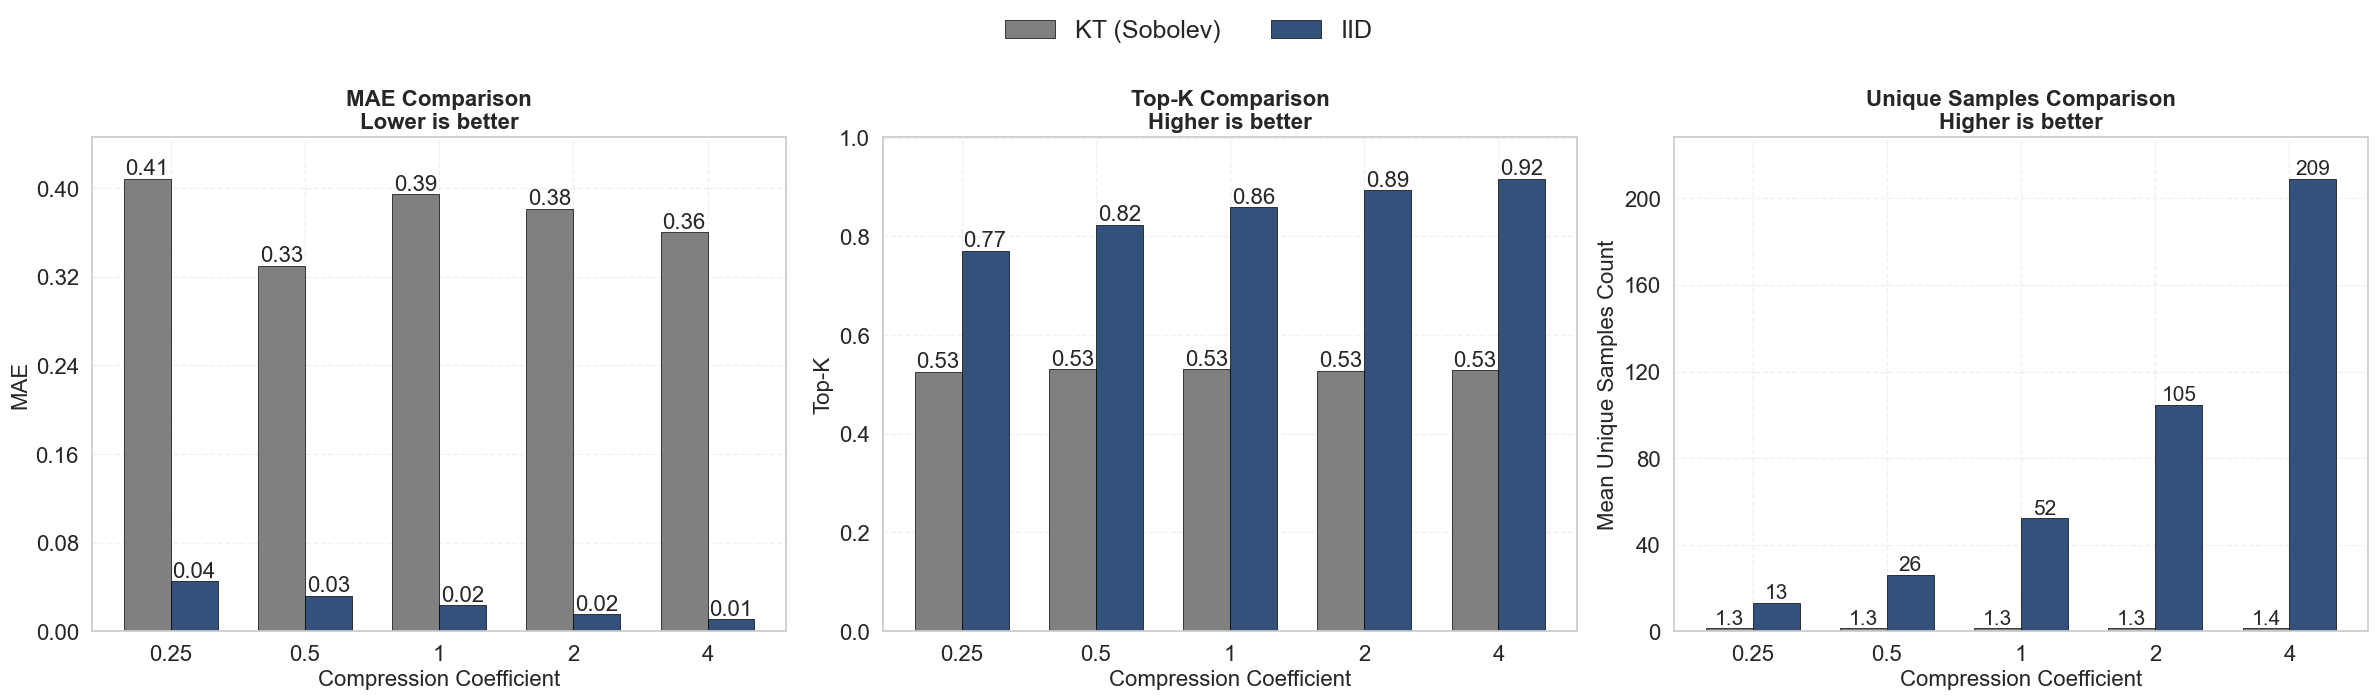

In [49]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
results_sobolev = results_aggregated[results_aggregated["method_total"] == "kt_sobolev"]
results_iid = results_aggregated[results_aggregated["method_total"] == "iid"]

data_cols = ["mae_mean", "top_k_mean", "unique_samples_mean"]
coeffs_to_keep = [0.25, 0.5, 1, 2, 4]

sobolev_agg = results_sobolev.groupby("compression_coefficient")[data_cols].mean().reset_index()
iid_agg = results_iid.groupby("compression_coefficient")[data_cols].mean().reset_index()

sobolev_agg = (
    sobolev_agg[sobolev_agg["compression_coefficient"].isin(coeffs_to_keep)]
    .sort_values("compression_coefficient")
)
iid_agg = (
    iid_agg[iid_agg["compression_coefficient"].isin(coeffs_to_keep)]
    .sort_values("compression_coefficient")
)

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 13

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

x_positions = np.arange(len(coeffs_to_keep))
bar_width = 0.35

sobolev_color = "gray"
iid_color = "#32527B"

# --- MAE ---
mae_sobolev = sobolev_agg["mae_mean"].values
mae_iid = iid_agg["mae_mean"].values

rects1 = axes[0].bar(
    x_positions - bar_width / 2,
    mae_sobolev,
    width=bar_width,
    color=sobolev_color,
    label="Sobolev",
    edgecolor="black",
    linewidth=0.5,
)
rects2 = axes[0].bar(
    x_positions + bar_width / 2,
    mae_iid,
    width=bar_width,
    color=iid_color,
    label="IID",
    edgecolor="black",
    linewidth=0.5,
)
axes[0].set_title("MAE Comparison\nLower is better", fontweight="bold")
axes[0].set_ylabel("MAE", fontsize=16)

for i, (val_sob, val_iid) in enumerate(zip(mae_sobolev, mae_iid)):
    axes[0].text(i - bar_width / 2, val_sob, f"{val_sob:.2f}", ha="center", va="bottom", fontsize=16)
    axes[0].text(i + bar_width / 2, val_iid, f"{val_iid:.2f}", ha="center", va="bottom", fontsize=16)

# --- Top-K ---
topk_sobolev = sobolev_agg["top_k_mean"].values
topk_iid = iid_agg["top_k_mean"].values

axes[1].bar(
    x_positions - bar_width / 2,
    topk_sobolev,
    width=bar_width,
    color=sobolev_color,
    edgecolor="black",
    linewidth=0.5,
)
axes[1].bar(
    x_positions + bar_width / 2,
    topk_iid,
    width=bar_width,
    color=iid_color,
    edgecolor="black",
    linewidth=0.5,
)
axes[1].set_title("Top-K Comparison\nHigher is better", fontweight="bold")
axes[1].set_ylabel("Top-K", fontsize=16)

for i, (val_sob, val_iid) in enumerate(zip(topk_sobolev, topk_iid)):
    axes[1].text(i - bar_width / 2, val_sob, f"{val_sob:.2f}", ha="center", va="bottom", fontsize=16)
    axes[1].text(i + bar_width / 2, val_iid, f"{val_iid:.2f}", ha="center", va="bottom", fontsize=16)

# --- Unique Samples ---
unique_sobolev = sobolev_agg["unique_samples_mean"].values
unique_iid = iid_agg["unique_samples_mean"].values

axes[2].bar(
    x_positions - bar_width / 2,
    unique_sobolev,
    width=bar_width,
    color=sobolev_color,
    edgecolor="black",
    linewidth=0.5,
)
axes[2].bar(
    x_positions + bar_width / 2,
    unique_iid,
    width=bar_width,
    color=iid_color,
    edgecolor="black",
    linewidth=0.5,
)
axes[2].set_title("Unique Samples Comparison\nHigher is better", fontweight="bold")
axes[2].set_ylabel("Mean Unique Samples Count", fontsize=16)

for i, (val_sob, val_iid) in enumerate(zip(unique_sobolev, unique_iid)):
    axes[2].text(i - bar_width / 2, val_sob, f"{val_sob:.1f}", ha="center", va="bottom", fontsize=15)
    axes[2].text(i + bar_width / 2, val_iid, f"{val_iid:.0f}", ha="center", va="bottom", fontsize=15)

# --- X axis formatting ---
for ax in axes:
    ax.set_xlabel("Compression Coefficient", fontsize=16)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(coeffs_to_keep, fontsize=16)

# --- Legend ---
fig.legend(
    [rects1, rects2],
    ["KT (Sobolev)", "IID"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=18,
    frameon=False,
)

for ax in axes:
    ax.tick_params(axis="y", labelsize=16)

# --- FIX: ensure the top y tick is visible (headroom + robust tick locator) ---
for ax in axes:
    y0, y1 = ax.get_ylim()
    ax.set_ylim(y0, y1 * 1.04)  # add headroom so top tick + labels don't get clipped
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))

plt.tight_layout()
plt.subplots_adjust(top=0.82)

os.makedirs("Image0", exist_ok=True)
fig.savefig(
    "Image0/sobolev_vs_iid_comparison.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
    pad_inches=0.2,  # extra padding helps prevent clipping in saved PDF
)

plt.show()


# Image 1 - 4 kernels + iid comparison

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

methods = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric", "kt_sobolev", "iid"]

sns.set_theme(style="whitegrid")

base_dir = "Image1"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name) &
                (results['method_total'].isin(methods))
            )
            filtered_results = results[mask]
            
            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []
            
            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_elements = []
            legend_labels = []

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list
                
                ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                
                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = data_plot.groupby(['size', 'method_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

                for method in methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue
                    
                    color = method_colors.get(method, "black")
                    
                    line = ax.errorbar(
                        x=method_data['size'], 
                        y=method_data['mean'], 
                        yerr=method_data['std_error'],
                        label=method, 
                        marker='o', 
                        capsize=13,
                        markeredgewidth=3, 
                        linewidth=4.5,      
                        markersize=12,      
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5 
                    )
                    
                    if idx == 0 and method not in legend_labels:
                        legend_elements.append(line)
                        legend_labels.append(method)
                
                ax.set_xscale('log')
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()}', fontsize=36, fontweight='bold')
                ax.set_ylim(bottom=0)
                
                ax.tick_params(axis='both', which='major', labelsize=32) 
                ax.tick_params(axis='both', which='minor', labelsize=24)
                
                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))
                ax.yaxis.get_offset_text().set_fontsize(30)

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            if legend_elements:
                sorted_indices = [methods.index(label) for label in legend_labels if label in methods]
                sorted_elements = [legend_elements[i] for i in sorted_indices]
                sorted_labels = [legend_labels[i] for i in sorted_indices]
                
                fig.legend(sorted_elements, sorted_labels, loc='lower center', ncol=len(methods), 
                          bbox_to_anchor=(0.5, -0.06), fontsize=36, title="METHODS", 
                          title_fontsize=40, frameon=True, shadow=True, borderpad=1.5)

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)

            file_name = f"{explainer_total}_{metric}.png"
            plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
            plt.close(fig) 

print("Process finished. All images are saved in Image1 folder.")

Process finished. All images are saved in Image1 folder.


# Image 2 - 3 kernels (- sobolev) + iid

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

methods = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric", "iid"]

sns.set_theme(style="whitegrid")

base_dir = "Image2"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name) &
                (results['method_total'].isin(methods))
            )
            filtered_results = results[mask]
            
            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []
            
            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_elements = []
            legend_labels = []

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list
                
                ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                
                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = data_plot.groupby(['size', 'method_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

                for method in methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue
                    
                    color = method_colors.get(method, "black")
                    
                    line = ax.errorbar(
                        x=method_data['size'], 
                        y=method_data['mean'], 
                        yerr=method_data['std_error'],
                        label=method, 
                        marker='o', 
                        capsize=13,
                        markeredgewidth=3, 
                        linewidth=4.5,      
                        markersize=12,      
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5 
                    )
                    
                    if idx == 0 and method not in legend_labels:
                        legend_elements.append(line)
                        legend_labels.append(method)
                
                ax.set_xscale('log')
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()}', fontsize=36, fontweight='bold')
                ax.set_ylim(bottom=0)
                
                ax.tick_params(axis='both', which='major', labelsize=32) 
                ax.tick_params(axis='both', which='minor', labelsize=24)
                
                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))
                ax.yaxis.get_offset_text().set_fontsize(30)

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            if legend_elements:
                sorted_indices = [methods.index(label) for label in legend_labels if label in methods]
                sorted_elements = [legend_elements[i] for i in sorted_indices]
                sorted_labels = [legend_labels[i] for i in sorted_indices]
                
                fig.legend(sorted_elements, sorted_labels, loc='lower center', ncol=len(methods), 
                          bbox_to_anchor=(0.5, -0.06), fontsize=36, title="METHODS", 
                          title_fontsize=40, frameon=True, shadow=True, borderpad=1.5)

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)

            file_name = f"{explainer_total}_{metric}.png"
            plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
            plt.close(fig) 

print("Process finished. All images are saved in Image2 folder.")

Process finished. All images are saved in Image2 folder.


# Image 3 - 3 kernels comparison (except sobolev)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

methods = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric"]

sns.set_theme(style="whitegrid")

base_dir = "Image3"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name) &
                (results['method_total'].isin(methods))
            )
            filtered_results = results[mask]
            
            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []
            
            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_elements = []
            legend_labels = []

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list
                
                ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                
                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = data_plot.groupby(['size', 'method_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

                for method in methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue
                    
                    color = method_colors.get(method, "black")
                    
                    line = ax.errorbar(
                        x=method_data['size'], 
                        y=method_data['mean'], 
                        yerr=method_data['std_error'],
                        label=method, 
                        marker='o', 
                        capsize=13,
                        markeredgewidth=3, 
                        linewidth=4.5,      
                        markersize=12,      
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5 
                    )
                    
                    if idx == 0 and method not in legend_labels:
                        legend_elements.append(line)
                        legend_labels.append(method)
                
                ax.set_xscale('log')
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()}', fontsize=36, fontweight='bold')
                ax.set_ylim(bottom=0)
                
                ax.tick_params(axis='both', which='major', labelsize=32) 
                ax.tick_params(axis='both', which='minor', labelsize=24)
                
                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))
                ax.yaxis.get_offset_text().set_fontsize(30)

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            if legend_elements:
                sorted_indices = [methods.index(label) for label in legend_labels if label in methods]
                sorted_elements = [legend_elements[i] for i in sorted_indices]
                sorted_labels = [legend_labels[i] for i in sorted_indices]
                
                fig.legend(sorted_elements, sorted_labels, loc='lower center', ncol=len(methods), 
                          bbox_to_anchor=(0.5, -0.06), fontsize=36, title="METHODS", 
                          title_fontsize=40, frameon=True, shadow=True, borderpad=1.5)

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)

            file_name = f"{explainer_total}_{metric}.png"
            plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
            plt.close(fig) 

print("Process finished. All images are saved in Image3 folder.")

Process finished. All images are saved in Image3 folder.


# Figure 4 - (kt_gaussian vs kt_predictions vs kt_stratified)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

base_methods = ["kt_gaussian", "iid", "kt_predictions"]
classification_only_methods = ["kt_stratified"]

sns.set_theme(style="whitegrid")

base_dir = "Image4"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name)
            )
            filtered_results = results[mask]
            
            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []
            
            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_handles = []
            legend_labels = []
            
            all_methods_for_legend = base_methods.copy()
            
            has_classification_datasets = len(classification_list) > 0
            
            if has_classification_datasets and "kt_stratified" not in all_methods_for_legend:
                all_methods_for_legend.append("kt_stratified")
            
            for method in all_methods_for_legend:
                color = method_colors.get(method, "black")
                line = plt.Line2D([0], [0], 
                                color=color, 
                                marker='o',
                                markersize=12,
                                linewidth=4.5,
                                markeredgewidth=3,
                                markeredgecolor=color,
                                label=method)
                legend_handles.append(line)
                legend_labels.append(method)

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list
                
                ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                
                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = data_plot.groupby(['size', 'method_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

                if is_regression:
                    dataset_methods = base_methods
                else:
                    dataset_methods = base_methods + classification_only_methods

                for method in dataset_methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue
                    
                    color = method_colors.get(method, "black")
                    
                    ax.errorbar(
                        x=method_data['size'], 
                        y=method_data['mean'], 
                        yerr=method_data['std_error'],
                        marker='o', 
                        capsize=13,
                        markeredgewidth=3, 
                        linewidth=4.5,      
                        markersize=12,      
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5 
                    )
                
                ax.set_xscale('log')
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()}', fontsize=36, fontweight='bold')
                
                y_min = grouped['mean'].min()
                y_max = grouped['mean'].max()
                if y_min >= 0:
                    ax.set_ylim(bottom=0)
                else:
                    ax.set_ylim(bottom=y_min * 1.05)
                
                ax.tick_params(axis='both', which='major', labelsize=32) 
                ax.tick_params(axis='both', which='minor', labelsize=24)
                
                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))
                ax.yaxis.get_offset_text().set_fontsize(30)

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            if legend_handles:
                fig.legend(legend_handles, legend_labels, 
                          loc='lower center', 
                          ncol=min(len(legend_labels), 4),
                          bbox_to_anchor=(0.5, -0.06), 
                          fontsize=36, 
                          title="METHODS", 
                          title_fontsize=40, 
                          frameon=True, 
                          shadow=True, 
                          borderpad=1.5)

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)

            file_name = f"{explainer_total}_{metric}.png"
            plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
            plt.close(fig) 

print("Process finished. All images are saved in Image4 folder.")

Process finished. All images are saved in Image4 folder.


# Image 5 - different baselines

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

all_legend_methods = ["stein_thinning", "arfpy", "iid", "kt_matern", "influence"]

sns.set_theme(style="whitegrid")

base_dir = "Image5"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name)
            )
            filtered_results = results[mask]
            
            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []
            
            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_elements = []
            legend_labels = []

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list
                
                ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                
                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = data_plot.groupby(['size', 'method_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

                for method in all_legend_methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue
                    
                    color = method_colors.get(method, "black")
                    
                    line = ax.errorbar(
                        x=method_data['size'], 
                        y=method_data['mean'], 
                        yerr=method_data['std_error'],
                        label=method, 
                        marker='o', 
                        capsize=13,
                        markeredgewidth=3, 
                        linewidth=4.5,      
                        markersize=12,      
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5 
                    )
                    
                    if idx == 0 and method not in legend_labels:
                        legend_elements.append(line)
                        legend_labels.append(method)
                
                ax.set_yscale('log') 
                
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()} (log)', fontsize=36, fontweight='bold') 
                
                ax.tick_params(axis='both', which='major', labelsize=32) 
                ax.tick_params(axis='both', which='minor', labelsize=24)
                
                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            from matplotlib.lines import Line2D
            
            sorted_elements = []
            sorted_labels = []
            
            for method in all_legend_methods:
                if method in legend_labels:
                    idx = legend_labels.index(method)
                    sorted_elements.append(legend_elements[idx])
                    sorted_labels.append(legend_labels[idx])
                else:
                    color = method_colors.get(method, "black")
                    proxy_line = Line2D([0], [0], color=color, linewidth=4.5, marker='o', 
                                       markersize=12, markeredgewidth=3, alpha=0.9)
                    sorted_elements.append(proxy_line)
                    sorted_labels.append(method)

            for i, label in enumerate(legend_labels):
                if label not in sorted_labels:
                    sorted_elements.append(legend_elements[i])
                    sorted_labels.append(label)
            
            fig.legend(sorted_elements, sorted_labels, loc='lower center', 
                      ncol=min(len(sorted_labels), 4),
                      bbox_to_anchor=(0.5, -0.06), fontsize=36, title="METHODS", 
                      title_fontsize=40, frameon=True, shadow=True, borderpad=1.5)

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)

            file_name = f"{explainer_total}_{metric}.png"
            plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
            plt.close(fig) 

print("Process finished. All images are saved in Image5 folder.")

Process finished. All images are saved in Image5 folder.


# Image 5.5 - kt for presentation

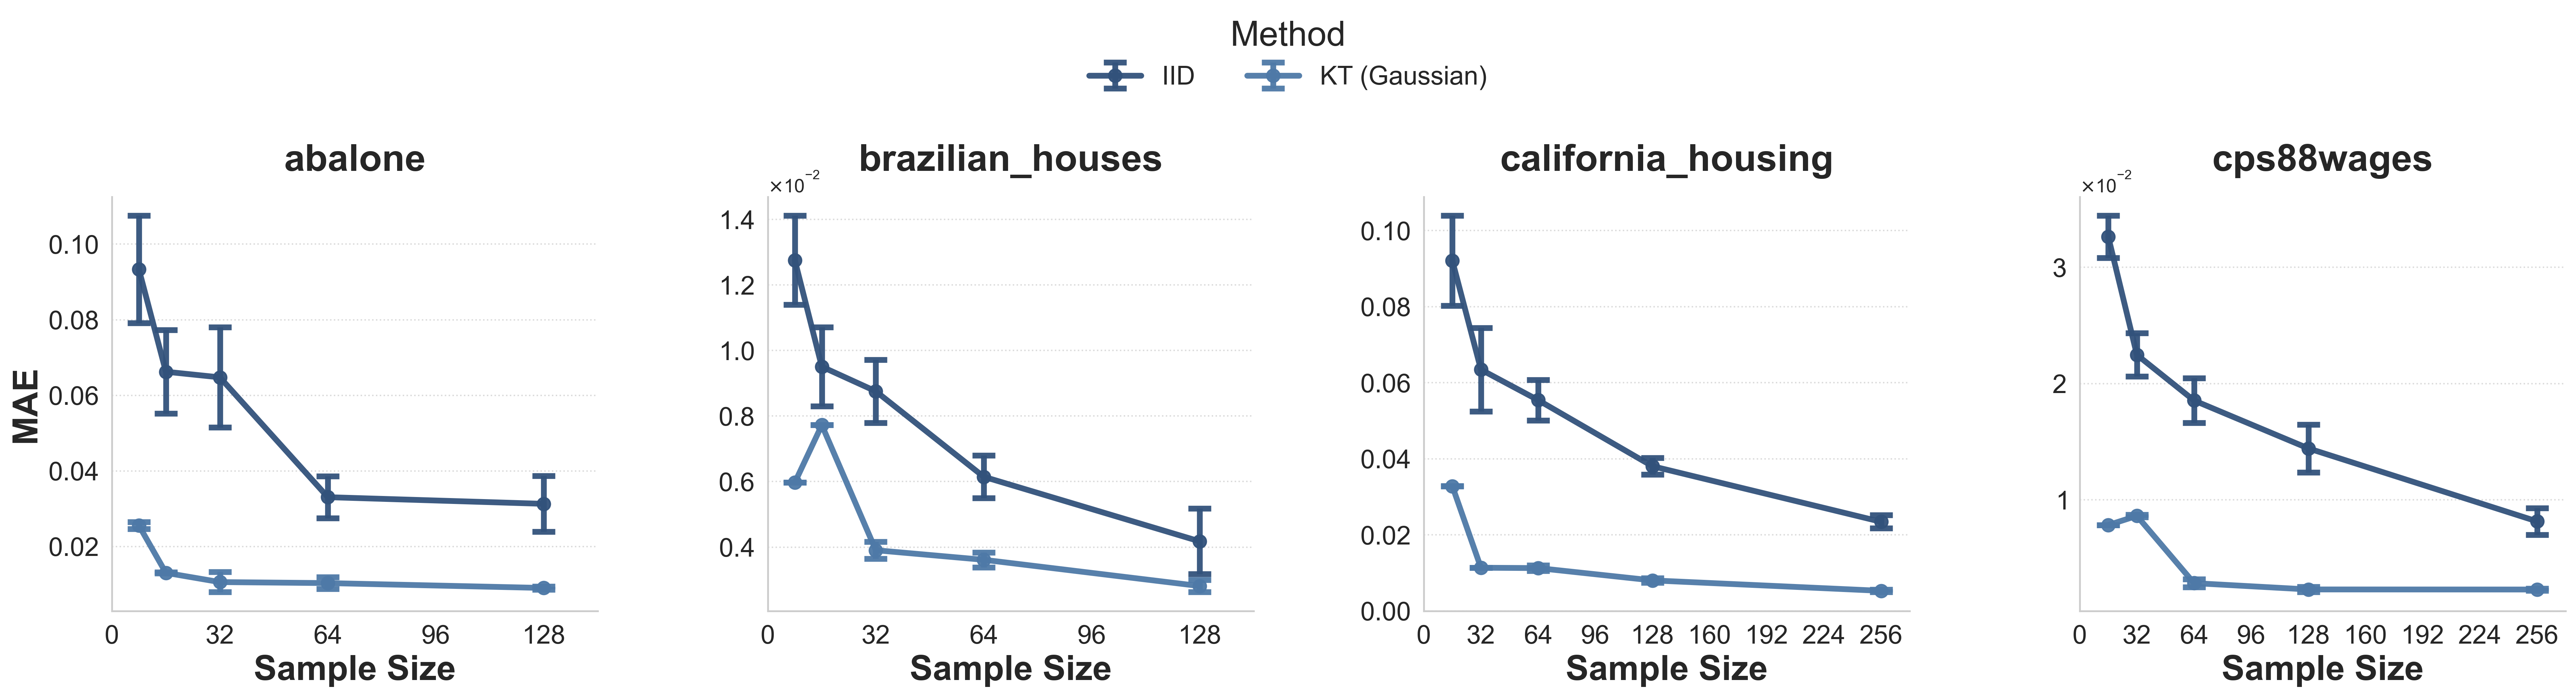

Process finished. All images are saved in Image5.5 folder.


In [52]:
import matplotlib.pyplot as plt
import numpy as np
import os
from math import ceil
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
# NIE ustawiaj seaborn theme, jeśli chcesz styl jak w przykładzie 2
# sns.set_theme(style="whitegrid")  # <-- usuń / zakomentuj

all_explainers = ["shap_kernel"]
all_metrics = ["mae"]
all_models = ['nn']
all_legend_methods = ["iid", "kt_gaussian"]

base_dir = "Image5.5"
os.makedirs(base_dir, exist_ok=True)

method_colors = {
    "kt_gaussian": "#4E79A7",
    "iid": "#32527B",
}
method_labels = {
    "iid": "IID",
    "kt_gaussian": "KT (Gaussian)",
}


for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)

    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name)
            )
            filtered_results = results[mask]

            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []

            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            # for dataset in unique_datasets:
            for dataset in ["abalone", "brazilian_houses", "california_housing", "cps88wages",]:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            # styl jak w przykładzie 2: wyższe dpi, bardziej "paper"
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 6), dpi=300)
            axes = np.atleast_1d(axes).flatten()

            legend_labels = []
            legend_elements = []

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list

                # możesz zostawić kolor tła jak chcesz; jeśli ma być "paper", daj białe
                # ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                ax.set_facecolor("white")

                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = (
                    data_plot.groupby(['size', 'method_total'])[metric]
                    .agg(['mean', 'std', 'count'])
                    .reset_index()
                )

                # w Twoim kodzie było std_error; w przykładzie 2 jest std
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'].clip(lower=1))

                for method in all_legend_methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue

                    color = method_colors.get(method, None)

                    # styl errorbar jak w przykładzie 2
                    line = ax.errorbar(
                        x=method_data['size'],
                        y=method_data['mean'],
                        yerr=method_data['std_error'],   # albo grouped['std'] jeśli wolisz jak w przykładzie 2
                        fmt='o-',
                        label=method,
                        color=color,
                        markersize=9,
                        capsize=8,
                        linewidth=4,
                        capthick=4,
                        alpha=0.95
                    )

                    if idx == 0 and method not in legend_labels:
                        legend_elements.append(line)
                        legend_labels.append(method)

                # === OŚ Y jak w przykładzie 2 (scientific), a NIE log ===
                ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
                ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

                # Oś X: zwykłe liczby (bez 1eX)
                ax.xaxis.set_major_formatter(ScalarFormatter())
                ax.ticklabel_format(axis='x', style='plain')

                ax.set_title(f'{dataset_name}', fontsize=26, fontweight='bold', pad=18)
                ax.xaxis.set_major_locator(MultipleLocator(32))
                xmin = grouped['size'].min()
                xmax = grouped['size'].max()
                ax.set_xlim((xmin // 32) * 32, ((xmax + 31) // 32) * 32+16)
                ax.set_xlabel('Sample Size', fontsize=24, fontweight='bold')
                # ax.set_ylabel(metric.upper(), fontsize=22, fontweight='bold')
                if idx % n_cols == 0:   # first column
                    ax.set_ylabel(metric.upper(), fontsize=24, fontweight='bold')
                else:
                    ax.set_ylabel("")

                ax.tick_params(axis='both', which='major', labelsize=18)

                # grid jak w przykładzie 2: tylko po Y, dotted
                ax.grid(axis='y', linestyle='dotted', alpha=0.7)
                ax.grid(axis='x', visible=False)

                # spines jak w przykładzie 2
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)

            # ukryj niewykorzystane osie
            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            # legenda (możesz zostawić globalną, jak masz)
            sorted_elements = []
            sorted_labels = []

            for method in all_legend_methods:
                if method in legend_labels:
                    j = legend_labels.index(method)
                    sorted_elements.append(legend_elements[j])
                    sorted_labels.append(method_labels.get(method, method))
                else:
                    color = method_colors.get(method, "black")
                    proxy = Line2D([0], [0], color=color, linewidth=2, marker='o',
                                   markersize=8, alpha=0.95)
                    sorted_elements.append(proxy)
                    sorted_labels.append(method_labels.get(method, method))

            fig.legend(
                sorted_elements, sorted_labels,
                loc='upper center',
                ncol=min(len(sorted_labels), 4),
                bbox_to_anchor=(0.5, 1.2),
                fontsize=18,
                title="Method",
                title_fontsize=24,
                frameon=False
            )

            fig.tight_layout(rect=[0, 0.06, 1, 1])
            fig.subplots_adjust(hspace=0.6, wspace=0.35)
            plt.show()
            file_name = f"{explainer_total}_{metric}.pdf"
            out_path = os.path.join(model_dir, file_name)

            fig.savefig(out_path, bbox_inches='tight')   # save FIRST
            # plt.show()                                 # optional: view interactively
            plt.close(fig)

print("Process finished. All images are saved in Image5.5 folder.")


# Image 12 - custom methods

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid")

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ["nn", "xgboost"]

base_methods = ["kt_gaussian", "iid", "kt_predictions"]
classification_only_methods = ["kt_stratified"]

base_dir = "Image12"
os.makedirs(base_dir, exist_ok=True)

model_styles = {
    "nn": "-",
    "xgboost": "--",
}

for explainer_total in all_explainers:
    for metric in all_metrics:

        filtered = results[results["explainer_total"] == explainer_total]
        if filtered.empty:
            continue

        datasets = sorted(filtered["dataset_name"].unique())
        if not datasets:
            continue

        n_cols = 4
        n_rows = ceil(len(datasets) / n_cols)

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(6.5 * n_cols, 4.8 * n_rows),
            sharex=False,
            sharey=False,
        )
        axes = np.atleast_1d(axes).flatten()

        for idx, dataset_name in enumerate(datasets):
            ax = axes[idx]

            ds_data = filtered[filtered["dataset_name"] == dataset_name]
            task_type = ds_data["task"].iloc[0]

            # Subtle background for task type
            ax.set_facecolor("#f2f8ff" if task_type == "regression" else "#fff5f5")

            grouped = (
                ds_data
                .groupby(["size", "method_total", "model_name"])[metric]
                .agg(["mean", "std", "count"])
                .reset_index()
            )
            grouped["stderr"] = grouped["std"] / np.sqrt(grouped["count"])

            methods_here = base_methods.copy()
            if task_type == "classification":
                methods_here += classification_only_methods

            for method in methods_here:
                for model in all_models:
                    sub = grouped[
                        (grouped["method_total"] == method) &
                        (grouped["model_name"] == model)
                    ]
                    if sub.empty:
                        continue

                    ax.errorbar(
                        sub["size"],
                        sub["mean"],
                        yerr=sub["stderr"],
                        color=method_colors.get(method, "black"),
                        linestyle=model_styles[model],
                        marker="o",
                        markersize=6,
                        linewidth=2.2,
                        capsize=4,
                        alpha=0.9,
                    )

            ax.set_xscale("log")
            ax.set_title(dataset_name, fontsize=14, pad=8)
            ax.set_xlabel("Sample size", fontsize=11)
            ax.set_ylabel(metric.replace("_", " ").upper(), fontsize=11)

            ymin = grouped["mean"].min()
            if ymin >= 0:
                ax.set_ylim(bottom=0)

            ax.tick_params(axis="both", labelsize=10)
            ax.grid(True, which="both", linestyle="--", alpha=0.4)

        # Hide unused axes
        for i in range(len(datasets), len(axes)):
            axes[i].set_visible(False)

        # ---------- LEGEND ----------
        method_handles = [
            Line2D([0], [0], color=method_colors[m], lw=3, label=m)
            for m in base_methods + classification_only_methods
            if m in filtered["method_total"].unique()
        ]

        model_handles = [
            Line2D([0], [0], color="black", lw=3, linestyle=model_styles[m], label=m.upper())
            for m in all_models
        ]

        fig.legend(
            handles=method_handles + model_handles,
            loc="lower center",
            ncol=4,
            fontsize=11,
            frameon=True,
            title="Compression method (color) / Model (line style)",
            title_fontsize=12,
            bbox_to_anchor=(0.5, -0.02),
        )

        fig.suptitle(
            f"{explainer_total.replace('_', ' ').title()} — {metric.replace('_', ' ').upper()}",
            fontsize=18,
            y=1.02,
        )

        plt.tight_layout()
        plt.savefig(
            os.path.join(base_dir, f"{explainer_total}_{metric}.png"),
            dpi=200,
            bbox_inches="tight",
        )
        plt.close(fig)

print("Done. Combined NN + XGB plots saved to Image12.")

Done. Combined NN + XGB plots saved to Image12.


# IMAGE 25

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

results = pd.read_csv("../package_metadata/results_all.csv")
filtered_results = results[
    (results["method_total"].isin(["kt_matern", "iid", "stein_thinning", "arfpy", "influence"])) &
    (results["model_name"] == "nn") &
    (results["explainer_total"].isin(["shap_kernel", "expected_gradients"])) &
    (results["dataset_name"].isin(["har", "texture", "optdigits", "spambase", "isolet", "satimage", "wilt", "letter"]))
]

sns.set_theme(style="whitegrid")

all_legend_methods = ["stein_thinning", "arfpy", "iid", "kt_matern", "influence"]

method_labels = {
    "kt_matern": "KT (Matérn)",
    "stein_thinning": "Stein Thinning",
    "arfpy": "ARF",
    "influence": "Influence",
    "iid": "IID",
}

output_dir = "Image25"
os.makedirs(output_dir, exist_ok=True)

datasets = sorted(filtered_results["dataset_name"].unique())

if datasets:
    regression_list = []
    classification_list = []
    
    for dataset in datasets:
        ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
        if not ds_data.empty:
            task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
            if task_type == 'regression':
                regression_list.append(dataset)
            else:
                classification_list.append(dataset)
    
    available_datasets = regression_list + classification_list
    
    n_cols = 4 
    n_rows = ceil(len(available_datasets) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8.5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for idx, dataset_name in enumerate(available_datasets):
        ax = axes[idx]
        is_regression = dataset_name in regression_list
        
        ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
        
        dataset_data = filtered_results[filtered_results["dataset_name"] == dataset_name]
        
        grouped = dataset_data.groupby(["size", "method_total"])["compression_time"].agg(['mean', 'std', 'count']).reset_index()
        grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

        for method in all_legend_methods:
            method_data = grouped[grouped['method_total'] == method]
            if method_data.empty:
                continue
            
            color = method_colors.get(method, "black")
            
            ax.errorbar(
                x=method_data['size'], 
                y=method_data['mean'], 
                yerr=method_data['std_error'],
                label=method_labels.get(method, method), 
                marker='o', 
                capsize=13,
                markeredgewidth=3, 
                linewidth=4.5,      
                markersize=12,      
                alpha=0.9,
                color=color,
                markeredgecolor=color,
                elinewidth=2.5 
            )
        
        ax.set_xscale('log')
        ax.set_yscale('log') 
        
        ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
        ax.set_xlabel('Compression Size', fontsize=36, fontweight='bold')
        ax.set_ylabel('Compression Time (s, log)', fontsize=36, fontweight='bold') 
        
        ax.tick_params(axis='both', which='major', labelsize=32) 
        ax.tick_params(axis='both', which='minor', labelsize=24)
        
        ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
        ax.xaxis.set_major_formatter(plt.ScalarFormatter())

    for i in range(len(available_datasets), len(axes)):
        axes[i].set_visible(False)

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    legend_elements = []
    for method in all_legend_methods:
        color = method_colors.get(method, "black")
        legend_elements.append(
            Line2D([0], [0], color=color, linewidth=4.5, marker='o',
                   markersize=12, markeredgewidth=3, alpha=0.9,
                   label=method_labels.get(method, method))
        )
    
    fig.legend(
        handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=len(all_legend_methods),
        fontsize=34,
        frameon=False,
        borderpad=1,
        handletextpad=1.5,
        columnspacing=2.5
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.98]) 
    plt.subplots_adjust(hspace=0.5, wspace=0.35)

    output_path = os.path.join(output_dir, "compression_time_grid_baselines.pdf")
    plt.savefig(output_path, bbox_inches='tight', dpi=100)
    plt.close(fig)
    
    print(f"Saved to: {output_path}")

print("Process finished. All images are saved in Image25 folder.")

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_8279/4123752221.py:7: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")


Saved to: Image25/compression_time_grid_baselines.pdf
Process finished. All images are saved in Image25 folder.


In [3]:
method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_inverse_multiquadric": "#F5B027",
    "kt_sobolev": "gray",
    "kt_predictions": "#895129",
    "kt_stratified": "#ff1493",
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#1F51FF",
}

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd
from math import ceil

results = pd.read_csv("../package_metadata/results_all.csv")
filtered_results = results[
    (results["method_total"].isin(["kt_gaussian", "iid", "stein_thinning", "arfpy", "influence"])) &
    (results["model_name"] == "nn") &
    (results["explainer_total"].isin(["shap_kernel", "expected_gradients"])) &
    (results["dataset_name"].isin(["har", "texture", "optdigits", "spambase", "isolet", "satimage", "wilt", "letter"]))
]

sns.set_theme(style="whitegrid")

all_legend_methods = ["stein_thinning", "arfpy", "iid", "kt_gaussian", "influence"]

method_labels = {
    "kt_gaussian": "KT (Gaussian)",
    "stein_thinning": "Stein Thinning",
    "arfpy": "ARF",
    "influence": "Influence",
    "iid": "IID",
}

output_dir = "Image25"
os.makedirs(output_dir, exist_ok=True)

datasets = sorted(filtered_results["dataset_name"].unique())

if datasets:
    regression_list = []
    classification_list = []
    
    for dataset in datasets:
        ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
        if not ds_data.empty:
            task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
            if task_type == 'regression':
                regression_list.append(dataset)
            else:
                classification_list.append(dataset)
    
    available_datasets = regression_list + classification_list
    
    n_cols = 4 
    n_rows = ceil(len(available_datasets) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8.5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for idx, dataset_name in enumerate(available_datasets):
        ax = axes[idx]
        is_regression = dataset_name in regression_list
        
        ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
        
        dataset_data = filtered_results[filtered_results["dataset_name"] == dataset_name]
        
        grouped = dataset_data.groupby(["size", "method_total"])["compression_time"].agg(['mean', 'std', 'count']).reset_index()
        grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

        for method in all_legend_methods:
            method_data = grouped[grouped['method_total'] == method]
            if method_data.empty:
                continue
            
            color = method_colors.get(method, "black")
            
            ax.errorbar(
                x=method_data['size'], 
                y=method_data['mean'], 
                yerr=method_data['std_error'],
                label=method_labels.get(method, method), 
                marker='o', 
                capsize=13,
                markeredgewidth=3, 
                linewidth=4.5,      
                markersize=12,      
                alpha=0.9,
                color=color,
                markeredgecolor=color,
                elinewidth=2.5 
            )
        
        ax.set_xscale('log')
        ax.set_yscale('log') 
        
        ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
        ax.set_xlabel('Compression Size', fontsize=36, fontweight='bold')
        ax.set_ylabel('Compression Time (s, log)', fontsize=36, fontweight='bold') 
        
        ax.tick_params(axis='both', which='major', labelsize=32) 
        ax.tick_params(axis='both', which='minor', labelsize=24)
        
        ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
        ax.xaxis.set_major_formatter(plt.ScalarFormatter())

    for i in range(len(available_datasets), len(axes)):
        axes[i].set_visible(False)

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    legend_elements = []
    for method in all_legend_methods:
        color = method_colors.get(method, "black")
        legend_elements.append(
            Line2D([0], [0], color=color, linewidth=4.5, marker='o',
                   markersize=12, markeredgewidth=3, alpha=0.9,
                   label=method_labels.get(method, method))
        )
    
    fig.legend(
        handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=len(all_legend_methods),
        fontsize=34,
        frameon=False,
        borderpad=1,
        handletextpad=1.5,
        columnspacing=2.5
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.98]) 
    plt.subplots_adjust(hspace=0.5, wspace=0.35)

    output_path = os.path.join(output_dir, "compression_time_grid_baselines_KT_gaussian.pdf")
    plt.savefig(output_path, bbox_inches='tight', dpi=100)
    plt.close(fig)
    
    print(f"Saved to: {output_path}")

print("Process finished. All images are saved in Image25 folder.")

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_26475/627674487.py:8: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")


Saved to: Image25/compression_time_grid_baselines_KT_gaussian.pdf
Process finished. All images are saved in Image25 folder.


# Image 26

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

all_legend_methods = ["kt_matern"]

sns.set_theme(style="whitegrid")

base_dir = "Image_26"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for metric in all_metrics:
        
        mask = (
            (results['method_total'] == 'kt_matern') &
            (results['model_name'] == model_name)
        )
        filtered_results = results[mask]
        
        if filtered_results.empty:
            continue

        regression_list = []
        classification_list = []
        
        unique_datasets = sorted(filtered_results['dataset_name'].unique())
        for dataset in unique_datasets:
            ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
            if not ds_data.empty and ds_data[metric].notna().any():
                task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                if task_type == 'regression':
                    regression_list.append(dataset)
                else:
                    classification_list.append(dataset)

        available_datasets = regression_list + classification_list
        if not available_datasets:
            continue

        n_cols = 4 
        n_rows = ceil(len(available_datasets) / n_cols)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
        axes = np.atleast_1d(axes).flatten()

        for idx, dataset_name in enumerate(available_datasets):
            ax = axes[idx]
            is_regression = dataset_name in regression_list
            
            ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
            
            dataset_data = filtered_results[filtered_results['dataset_name'] == dataset_name]
            
            grouped = dataset_data.groupby(['size', 'explainer_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
            grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

            for explainer in all_explainers:
                explainer_data = grouped[grouped['explainer_total'] == explainer]
                if explainer_data.empty:
                    continue
                
                explainer_colors = {
                    "expected_gradients": "#1f77b4",
                    "shap_kernel": "#ff7f0e", 
                    "sage_permutation": "#2ca02c",
                    "shapiq_kernel": "#d62728"
                }
                
                color = explainer_colors.get(explainer, "black")
                
                ax.errorbar(
                    x=explainer_data['size'], 
                    y=explainer_data['mean'], 
                    yerr=explainer_data['std_error'],
                    label=explainer.replace('_', ' ').title(), 
                    marker='o', 
                    capsize=13,
                    markeredgewidth=3, 
                    linewidth=4.5,      
                    markersize=12,      
                    alpha=0.9,
                    color=color,
                    markeredgecolor=color,
                    elinewidth=2.5 
                )
            
            ax.set_xscale('log')
            ax.set_yscale('log') 
            
            ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
            ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
            ax.set_ylabel(f'{metric.upper()} (log)', fontsize=36, fontweight='bold') 
            
            ax.tick_params(axis='both', which='major', labelsize=32) 
            ax.tick_params(axis='both', which='minor', labelsize=24)
            
            ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
            ax.xaxis.set_major_formatter(plt.ScalarFormatter())

        for i in range(len(available_datasets), len(axes)):
            axes[i].set_visible(False)

        from matplotlib.lines import Line2D
        
        explainer_colors = {
            "expected_gradients": "#1f77b4",
            "shap_kernel": "#ff7f0e", 
            "sage_permutation": "#2ca02c",
            "shapiq_kernel": "#d62728"
        }
        
        legend_elements = []
        for explainer in all_explainers:
            color = explainer_colors.get(explainer, "black")
            legend_elements.append(
                Line2D([0], [0], color=color, linewidth=4.5, marker='o',
                       markersize=12, markeredgewidth=3, alpha=0.9,
                       label=explainer.replace('_', ' ').title())
            )
        fig.legend(handles=legend_elements, loc='lower center', 
                  ncol=min(len(all_explainers), 4),
                  bbox_to_anchor=(0.5, -0.06), fontsize=36, title="EXPLAINERS", 
                  title_fontsize=40, frameon=True, shadow=True, borderpad=1.5)

        plt.tight_layout(rect=[0, 0, 1, 1])
        plt.subplots_adjust(hspace=0.8, wspace=0.45)

        file_name = f"{model_name}_{metric}_kt_matern_explainers.png"
        plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
        plt.close(fig) 

print("Process finished. All images are saved in Image5_kt_matern_only folder.")

Process finished. All images are saved in Image5_kt_matern_only folder.


## image 29

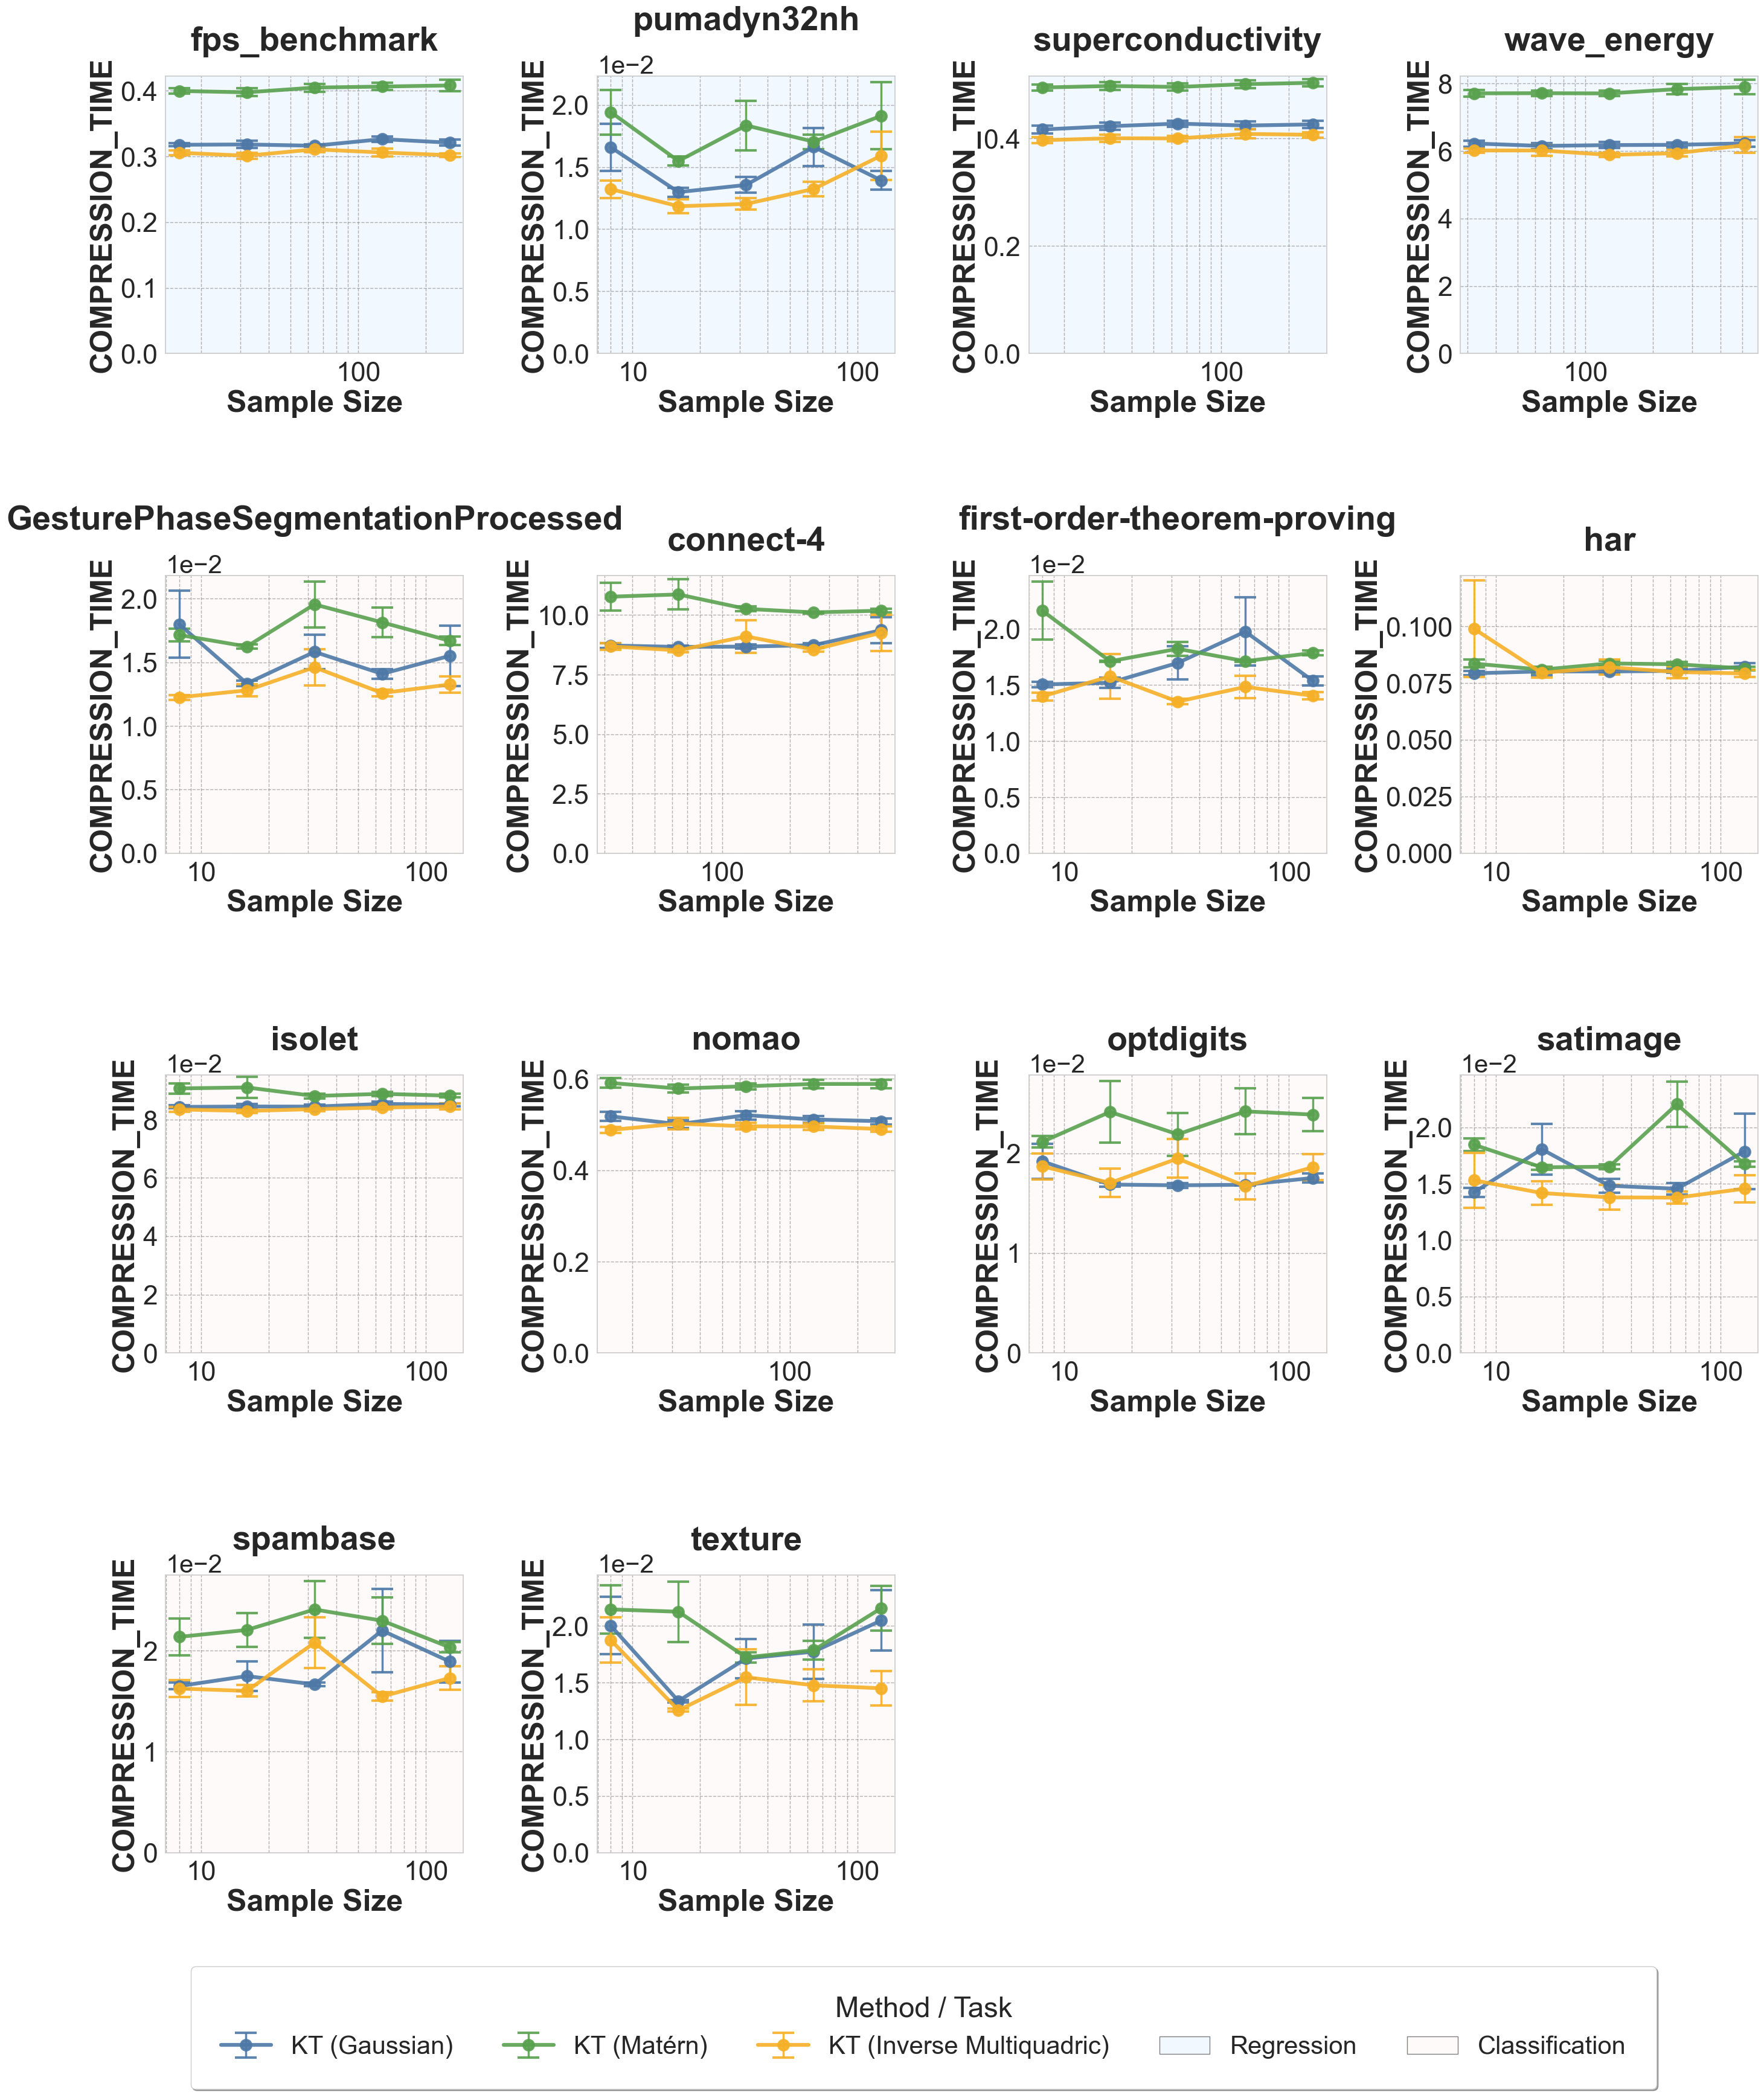

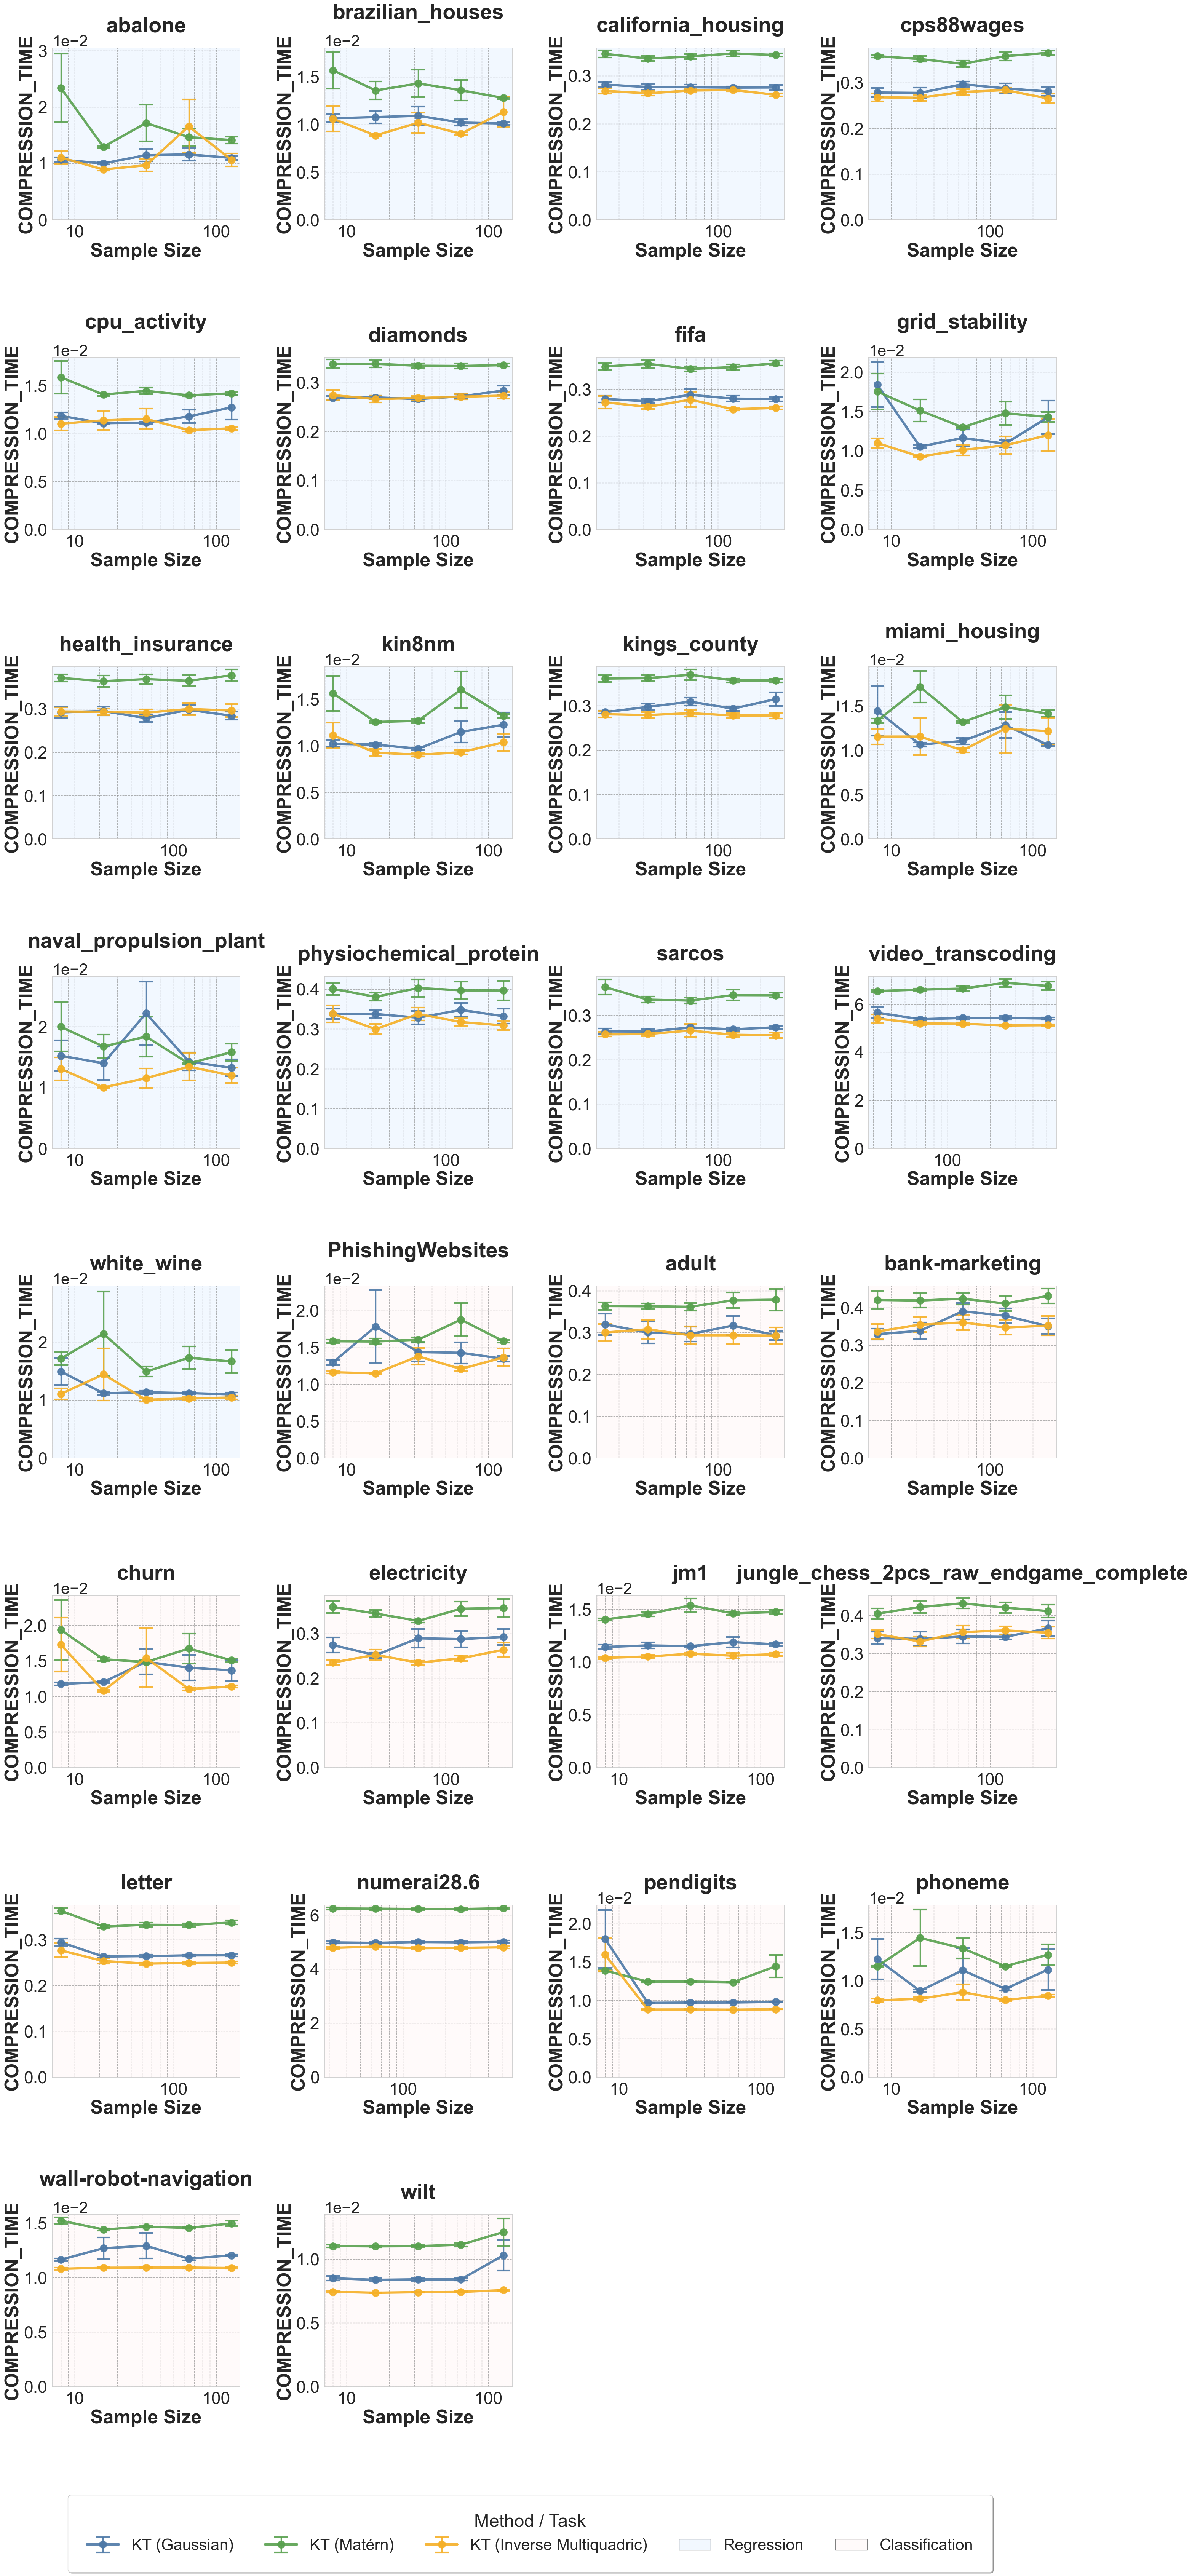

Process finished. All images are saved in Image29 folder.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil
from matplotlib.patches import Patch

all_explainers = ["expected_gradients", "shap_kernel"]
all_metrics = ["compression_time"]
all_models = ['nn']

methods = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric"]
method_labels = {
    "kt_gaussian": "KT (Gaussian)",
    "kt_matern": "KT (Matérn)",
    "kt_inverse_multiquadric": "KT (Inverse Multiquadric)",
}

# make sure you have this dict defined somewhere (you used it below)
# example:
# method_colors = {
#     "kt_gaussian": "#4E79A7",
#     "kt_matern": "#F28E2B",
#     "kt_inverse_multiquadric": "#59A14F",
# }

sns.set_theme(style="whitegrid")

base_dir = "Image29"
os.makedirs(base_dir, exist_ok=True)

# background colors (blue/pink meaning)
REG_BG = "#f2f8ff"
CLS_BG = "#fffafa"

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)

    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name) &
                (results['method_total'].isin(methods))
            )
            filtered_results = results[mask]

            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []

            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_elements = []
            legend_method_keys = []  # store method keys

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list

                ax.set_facecolor(REG_BG if is_regression else CLS_BG)

                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = (
                    data_plot.groupby(['size', 'method_total'])[metric]
                    .agg(['mean', 'std', 'count'])
                    .reset_index()
                )
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'].clip(lower=1))

                for method in methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue

                    color = method_colors.get(method, "black")

                    line = ax.errorbar(
                        x=method_data['size'],
                        y=method_data['mean'],
                        yerr=method_data['std_error'],
                        label=method,   # keep key; map later
                        marker='o',
                        capsize=13,
                        markeredgewidth=3,
                        linewidth=4.5,
                        markersize=12,
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5
                    )

                    if idx == 0 and method not in legend_method_keys:
                        legend_elements.append(line)
                        legend_method_keys.append(method)

                ax.set_xscale('log')
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()}', fontsize=36, fontweight='bold')
                ax.set_ylim(bottom=0)

                ax.tick_params(axis='both', which='major', labelsize=32)
                ax.tick_params(axis='both', which='minor', labelsize=24)

                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
                ax.yaxis.get_offset_text().set_fontsize(30)

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            # ---- Legend using method_labels + add pink/blue meaning ----
            if legend_elements:
                ordered_methods = [m for m in methods if m in legend_method_keys]
                ordered_elements = [legend_elements[legend_method_keys.index(m)] for m in ordered_methods]
                ordered_labels = [method_labels.get(m, m) for m in ordered_methods]

                # add dataset background meaning (blue/pink)
                dataset_handles = [
                    Patch(facecolor=REG_BG, edgecolor="gray", label="Regression"),
                    Patch(facecolor=CLS_BG, edgecolor="gray", label="Classification"),
                ]

                handles = ordered_elements + dataset_handles
                labels = ordered_labels + [h.get_label() for h in dataset_handles]

                # Make legend a bit lower ONLY for Expected Gradients
                legend_y = -0.09 if explainer_total == "expected_gradients" else -0.06
                # (tweak legend_y if you want even lower/higher)

                fig.legend(
                    handles,
                    labels,
                    loc='lower center',
                    ncol=max(1, len(labels)),      # one row; change if too wide
                    bbox_to_anchor=(0.5, legend_y),
                    fontsize=30,
                    title="Method / Task",
                    title_fontsize=34,
                    frameon=True,
                    shadow=True,
                    borderpad=1.2
                )

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)
            plt.show()
            # ---- Save to PDF ----
            file_name = f"{explainer_total}_{metric}.pdf"
            out_path = os.path.join(model_dir, file_name)
            fig.savefig(out_path, bbox_inches='tight')
            plt.close(fig)

print("Process finished. All images are saved in Image29 folder.")
